### Used libraries

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

### Load datasets from csv

In [12]:
df = pd.read_csv('datasets/job_offer_with_skills.csv', delimiter= ',')
df = df.drop('Unnamed: 0', axis=1)
print(df.shape)
df.head()

(5935, 10)


,profil,market_category,societe,type_contrat,lieu_clean,limite_date,offers_date,title_clean,mission_clean,profil_clean
0,o solides connaissances en electronique indust...,Ingénierie / industrie / BTP,groupe sipromad,contrat cdi,antananarivo,0001-01-01,13/05/2025,electronicien,l électronicien industriel est maintenance rép...,o solides connaissances electronique industrie...
1,- formation bac+3 a bac+5 en informatique\n- m...,Informatique / web,astek madagascar,contrat cdd,antananarivo,0001-01-01,28/09/2024,c c engineer,participez à projets transformation digitale v...,formation bac bac informatique maitrise techno...
2,"• bac +4/5 en gestion, grh, sociologie, droit,...",Management / RH,inviso group,contrat cdi,antananarivo,0001-01-01,14/02/2025,developpement rh,rattaché à directrice ressources humaines grou...,bac gestion grh sociologie droit psychologie m...
3,"titulaire d'un bac+ 4/5 en economie,marketing,...",Marketing / Communication,boost>,contrat cdi,antananarivo,0001-01-01,17/02/2025,charge commercial,poste basé à tanjombato chargé veille économiq...,titulaire d bac economie marketing sociologie ...
4,"le candidat ideal possede un bac+2 minimum, un...",Ingénierie / industrie / BTP,copilotas madagascar,contrat cdi,antananarivo,0001-01-01,05/12/2024,projeteur coffrage ferraillage,nous recrutons projeteur génie civil béton arm...,candidat ideal possede bac minimum solide expe...


### Job offers by contract type

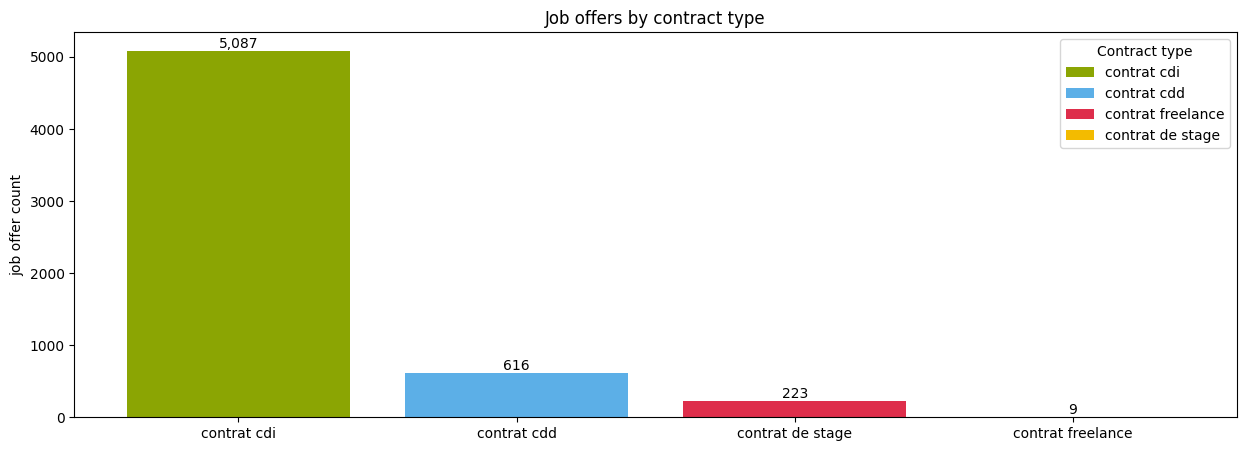

In [3]:
fig, ax = plt.subplots(figsize = (15,5))

job_offer_count = df[df['type_contrat'].isin(['contrat cdi', 'contrat cdd', 'contrat freelance', 'contrat de stage'])]['type_contrat'].value_counts().index
contract_type = df[df['type_contrat'].isin(['contrat cdi', 'contrat cdd', 'contrat freelance', 'contrat de stage'])]['type_contrat'].value_counts().values
bar_labels = ['contrat cdi', 'contrat cdd', 'contrat freelance', 'contrat de stage']
bar_colors = ['#8BA503', '#5CAFE7', '#DE2E4B', '#F3BB00']

bars = ax.bar(job_offer_count, contract_type, label=bar_labels, color=bar_colors)
ax.bar_label(bars, fmt='{:,.0f}')
ax.set_ylabel('job offer count')
ax.set_title('Job offers by contract type')
ax.legend(title='Contract type')
plt.show()

### Localizations that hire the most

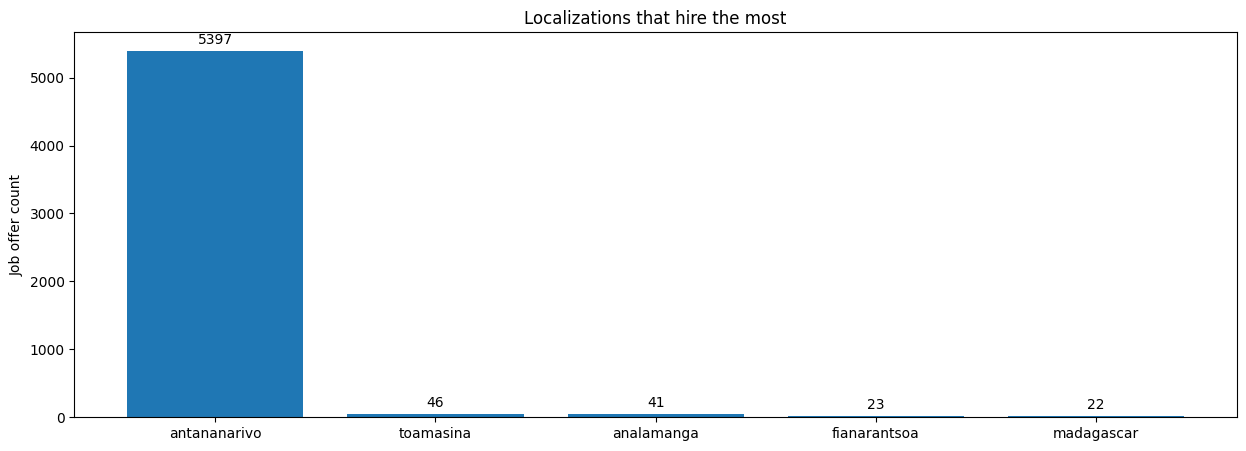

In [4]:
fig, ax = plt.subplots(figsize=(15,5))

localization = df['lieu_clean'].value_counts().head()

bars = ax.bar(localization.index, localization.values, color='tab:blue')

ax.bar_label(bars, padding=3)

ax.set_ylabel('Job offer count')
ax.set_title('Localizations that hire the most')
plt.show()

### Companies that hire the most

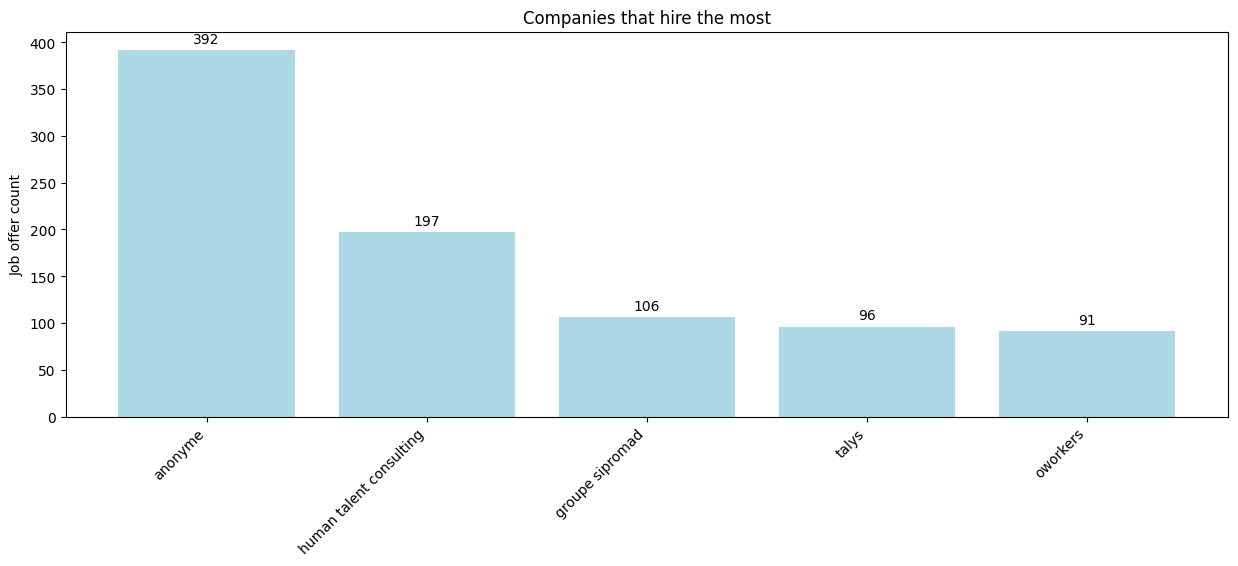

In [5]:
fig, ax = plt.subplots(figsize=(15,5))

society = df['societe'].value_counts().head()

bars = ax.bar(society.index, society.values, color='#ADD8E6')

ax.bar_label(bars, padding=3)
ax.set_ylabel('Job offer count')
ax.set_title('Companies that hire the most')
plt.xticks(rotation=45, ha='right')
plt.show()

### Job offers trend between july 2024 -  july 2025

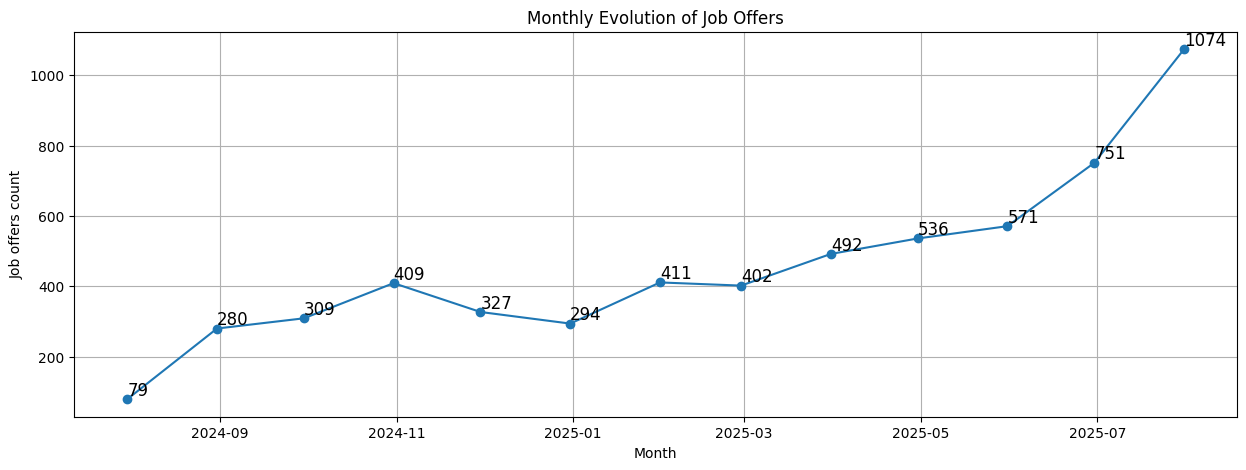

In [6]:
df['offers_date'] = pd.to_datetime(df['offers_date'], format='%d/%m/%Y')

monthly_counts = df.resample('ME', on='offers_date').size()

fig, ax = plt.subplots(figsize=(15,5))

ax.plot(monthly_counts.index, monthly_counts.values, marker='o')

for x, y in zip(monthly_counts.index, monthly_counts.values):
    ax.text(x, y, str(y), va='bottom', fontsize=12)

ax.set(
    xlabel='Month',
    ylabel='Job offers count',
    title='Monthly Evolution of Job Offers'
)

ax.grid(True)
plt.show()

### Evolution of TOP 5 job categories over months

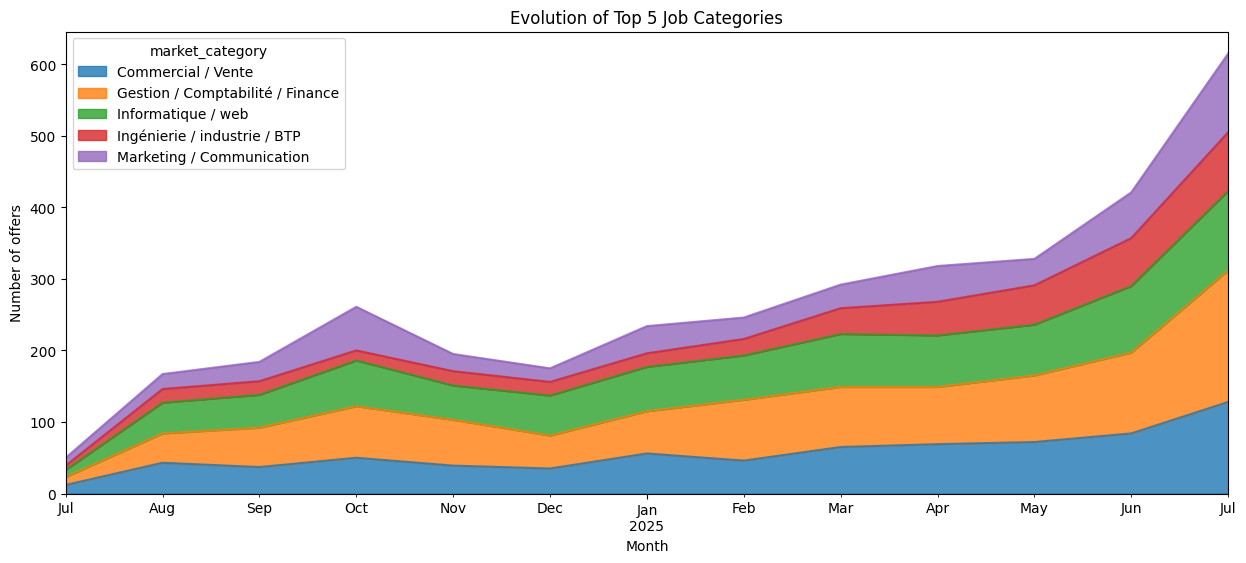

In [7]:
df['offers_date'] = pd.to_datetime(df['offers_date'], format='%d/%m/%Y')

top5 = df['market_category'].value_counts().head(5).index
df_top = df[df['market_category'].isin(top5)]
monthly_category = (
    df_top
    .groupby([pd.Grouper(key='offers_date', freq='ME'), 'market_category'])
    .size()
    .unstack()
)
fig, ax = plt.subplots(figsize=(15,6))

monthly_category.plot(
    kind='area',
    stacked=True,
    ax=ax,
    alpha=0.8
)

ax.set(
    xlabel='Month',
    ylabel='Number of offers',
    title='Evolution of Top 5 Job Categories'
)

plt.show()